# Visualization & Evaluation

## Overview
High-dimensional cluster structure is difficult to interpret directly. This notebook
projects the PCA-reduced data into two dimensions using **t-SNE** and **UMAP**, then
compares the visual structure against the clustering results. It also computes three
quantitative metrics that measure how well each algorithm recovered the known cancer
subtypes.

## Dimensionality reduction methods for visualization

### t-SNE (t-distributed Stochastic Neighbour Embedding)
t-SNE converts high-dimensional pairwise similarities into a 2D layout. It excels at
revealing local cluster structure — samples that are close together in high-dimensional
space tend to appear as tight islands in the 2D plot. The `perplexity` parameter
(set to 30) controls the effective number of neighbours considered for each point.
t-SNE does **not** preserve global distances, so the spacing between clusters should
not be over-interpreted.

### UMAP (Uniform Manifold Approximation and Projection)
UMAP learns the underlying manifold of the data and projects it into 2D. Compared to
t-SNE, UMAP better preserves global structure (relative distances between clusters
are more meaningful) and is significantly faster. `n_neighbors=15` and `min_dist=0.1`
are standard defaults that balance local vs global structure.

## Evaluation metrics

| Metric | What it measures | Range |
|---|---|---|
| **Silhouette Score** | Cohesion (compactness within clusters) vs separation (distance between clusters). Does **not** require ground truth. | −1 to +1 (higher = better) |
| **ARI (Adjusted Rand Index)** | Agreement between predicted clusters and true labels, corrected for chance. Requires ground truth. | −1 to +1 (1 = perfect) |
| **NMI (Normalised Mutual Information)** | Shared information between predicted clusters and true labels, normalised to [0, 1]. Requires ground truth. | 0 to 1 (1 = perfect) |

## Inputs
- `data/X_pca.csv` — PCA-reduced feature matrix
- `data/labels.csv` — ground-truth cancer subtype labels
- `data/cluster_assignments.csv` — predictions from the clustering notebook

## Outputs
- `data/X_tsne.csv` — 2D t-SNE coordinates for all samples
- `data/X_umap.csv` — 2D UMAP coordinates for all samples
- `data/eval_metrics.csv` — Silhouette / ARI / NMI for every algorithm
- `models/umap.joblib` — fitted UMAP model (used by the Streamlit app to project new samples)
- `reports/figures/tsne_projections.png`
- `reports/figures/umap_projections.png`
- `reports/figures/evaluation_metrics.png`
- `reports/figures/best_contingency_matrix.png`

## 0. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from umap import UMAP

DATA_DIR    = "../data"
MODELS_DIR  = "../models"
FIGURES_DIR = "../reports/figures"

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

## 1. Load Data & Cluster Assignments

In [2]:
X_pca       = pd.read_csv(f"{DATA_DIR}/X_pca.csv", index_col=0).values
assignments = pd.read_csv(f"{DATA_DIR}/cluster_assignments.csv", index_col=0)

true_labels   = assignments["true_label"]
cluster_cols  = [c for c in assignments.columns if c != "true_label"]

print(f"Samples     : {X_pca.shape[0]}")
print(f"PCA dims    : {X_pca.shape[1]}")
print(f"Algorithms  : {cluster_cols}")

Samples     : 801
PCA dims    : 548
Algorithms  : ['kmeans_k5', 'agg_ward', 'agg_complete', 'agg_average']


## 2. t-SNE Projection

In [3]:
print("Fitting t-SNE …")
tsne   = TSNE(n_components=2, perplexity=30, learning_rate="auto",
              init="pca", random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca)
print(f"t-SNE done  — shape {X_tsne.shape}")

Fitting t-SNE …
t-SNE done  — shape (801, 2)


## 3. UMAP Projection

In [4]:
print("Fitting UMAP …")
umap_model = UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                  random_state=RANDOM_STATE)
X_umap     = umap_model.fit_transform(X_pca)
print(f"UMAP done   — shape {X_umap.shape}")

Fitting UMAP …


/home/mk/.venvs/cancer/lib/python3.12/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP done   — shape (801, 2)


## 4. Scatter Plots — True Labels vs Cluster Assignments

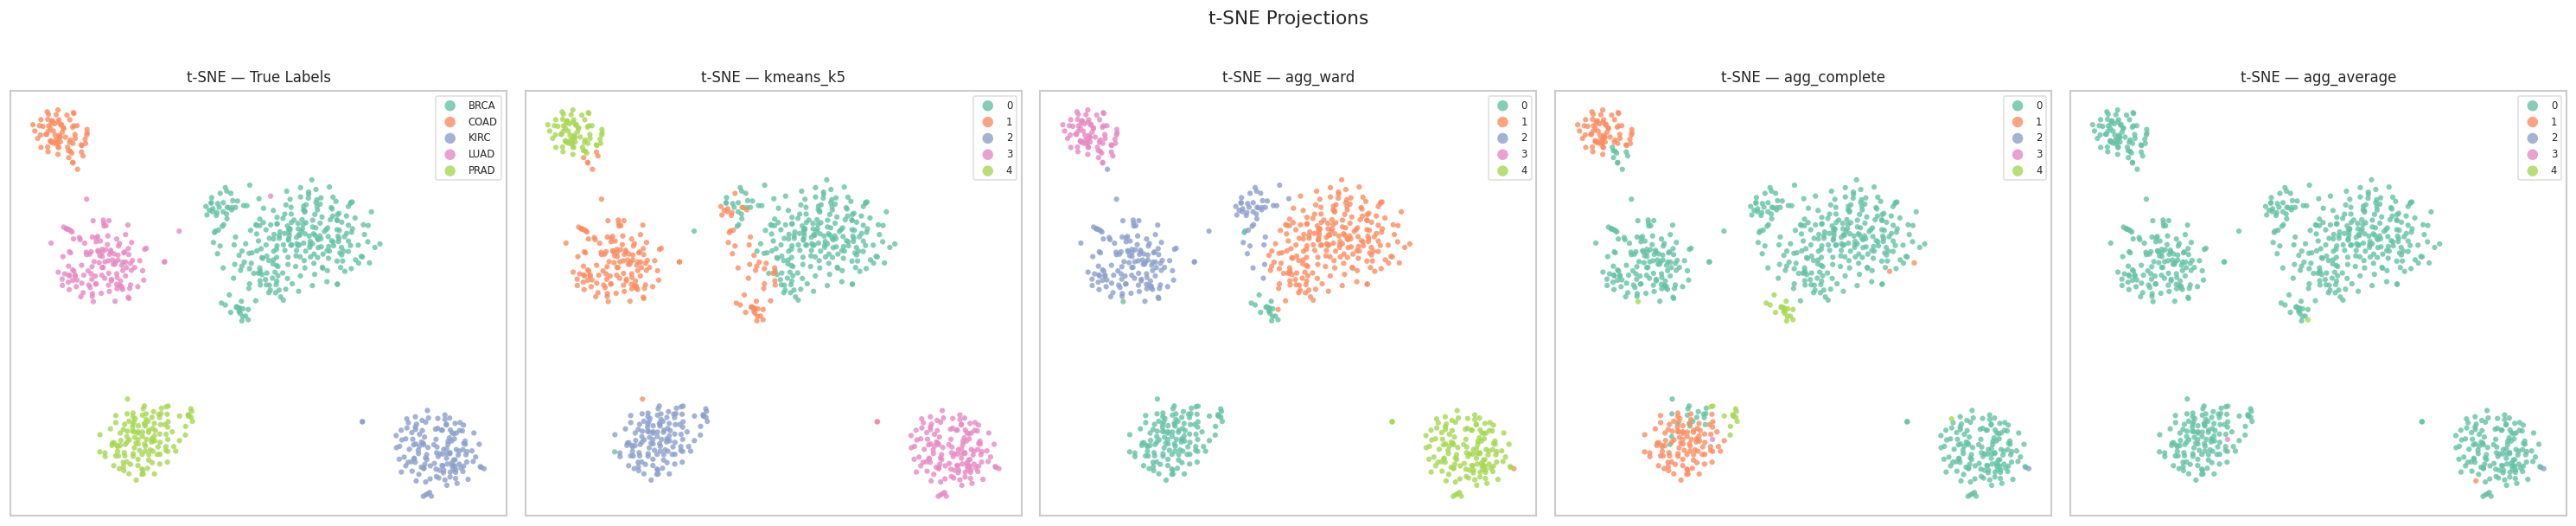

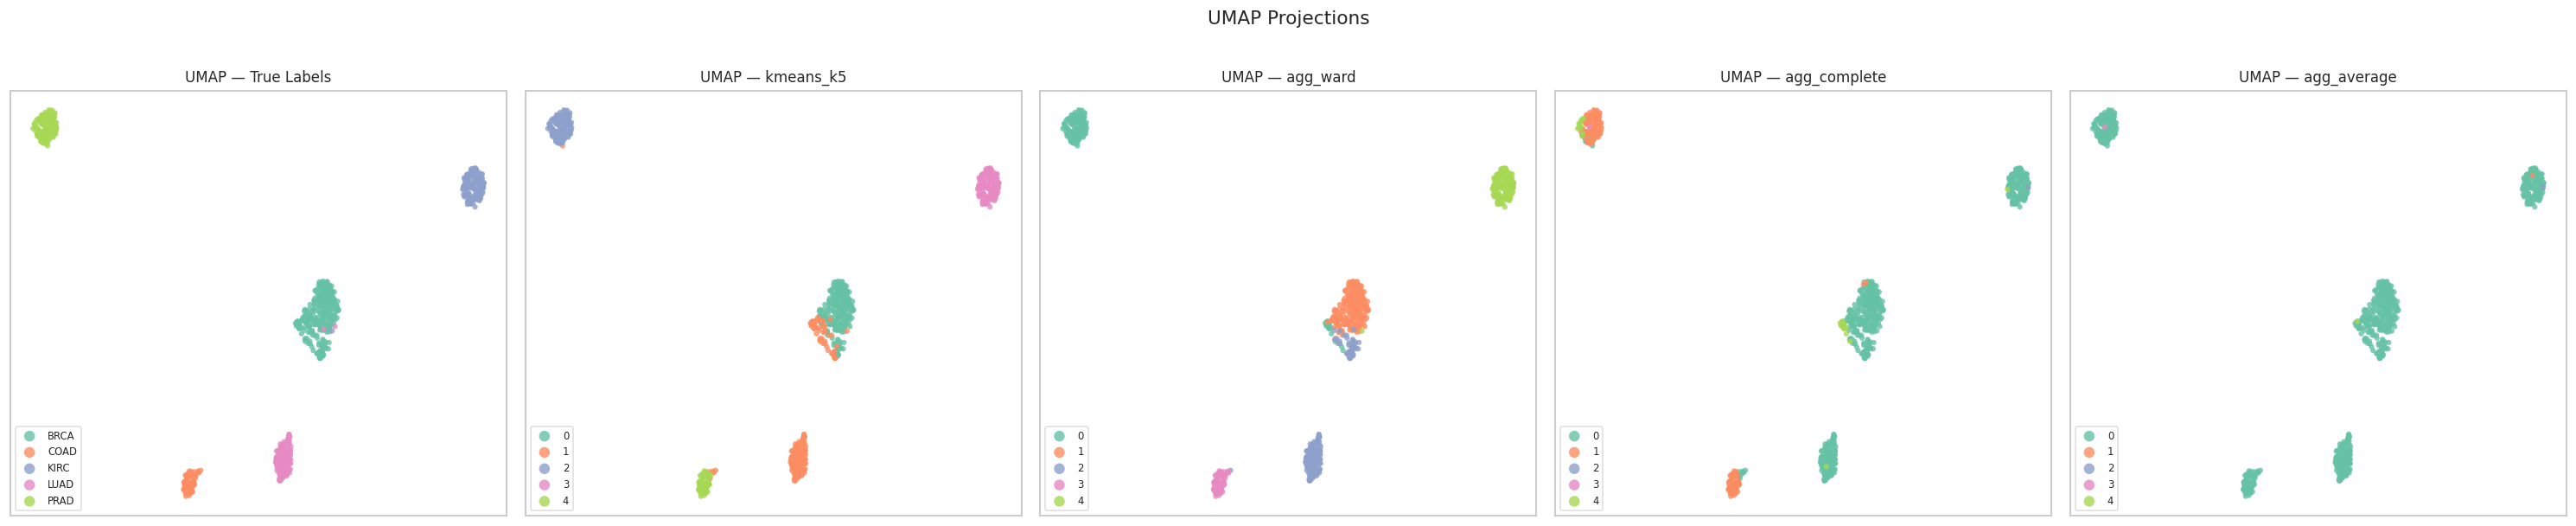

In [5]:
def scatter_2d(ax, coords, color_series, title, palette=None):
    """Generic 2-D scatter coloured by a categorical series."""
    categories = sorted(color_series.unique())
    if palette is None:
        palette = sns.color_palette("Set2", len(categories))
    color_map = dict(zip(categories, palette))
    for cat in categories:
        mask = color_series == cat
        ax.scatter(coords[mask, 0], coords[mask, 1],
                   s=14, alpha=0.8, edgecolors="none",
                   color=color_map[cat], label=str(cat))
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(markerscale=2, fontsize=7, loc="best", framealpha=0.6)


# --- t-SNE grid ---
n_cols  = 1 + len(cluster_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

scatter_2d(axes[0], X_tsne, true_labels, "t-SNE — True Labels")
for i, col in enumerate(cluster_cols):
    scatter_2d(axes[i + 1], X_tsne, assignments[col],
               f"t-SNE — {col}")

plt.suptitle("t-SNE Projections", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/tsne_projections.png", bbox_inches="tight")
plt.show()

# --- UMAP grid ---
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))

scatter_2d(axes[0], X_umap, true_labels, "UMAP — True Labels")
for i, col in enumerate(cluster_cols):
    scatter_2d(axes[i + 1], X_umap, assignments[col],
               f"UMAP — {col}")

plt.suptitle("UMAP Projections", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/umap_projections.png", bbox_inches="tight")
plt.show()

## 5. Quantitative Evaluation

In [6]:
rows = []
for col in cluster_cols:
    pred = assignments[col]
    rows.append({
        "Algorithm" : col,
        "Silhouette": silhouette_score(X_pca, pred),
        "ARI"       : adjusted_rand_score(true_labels, pred),
        "NMI"       : normalized_mutual_info_score(true_labels, pred),
    })

metrics = pd.DataFrame(rows).sort_values("ARI", ascending=False)
metrics[["Silhouette", "ARI", "NMI"]] = metrics[["Silhouette", "ARI", "NMI"]].applymap("{:.4f}".format)
print(metrics.to_string(index=False))

   Algorithm Silhouette    ARI    NMI
   kmeans_k5     0.1420 0.7927 0.8524
    agg_ward     0.1397 0.7798 0.8396
agg_complete     0.0786 0.2402 0.3794
 agg_average     0.2645 0.0004 0.0099


/tmp/ipykernel_63201/3277432972.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  metrics[["Silhouette", "ARI", "NMI"]] = metrics[["Silhouette", "ARI", "NMI"]].applymap("{:.4f}".format)


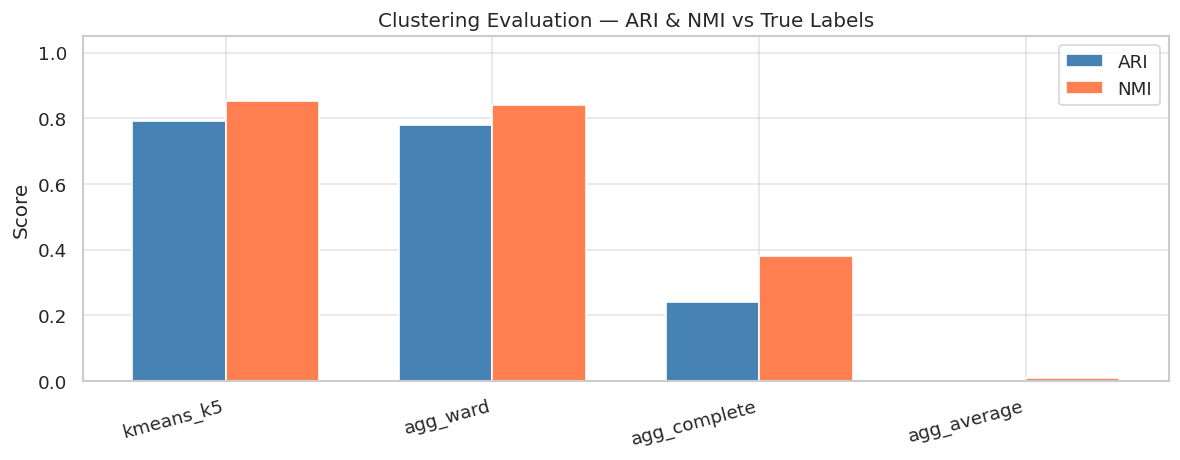

In [7]:
# Bar chart — ARI and NMI side by side
metrics_num = pd.DataFrame(rows).sort_values("ARI", ascending=False)

x     = np.arange(len(metrics_num))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width / 2, metrics_num["ARI"],  width, label="ARI",  color="steelblue")
ax.bar(x + width / 2, metrics_num["NMI"],  width, label="NMI",  color="coral")

ax.set_xticks(x)
ax.set_xticklabels(metrics_num["Algorithm"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("Clustering Evaluation — ARI & NMI vs True Labels")
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/evaluation_metrics.png")
plt.show()

## 6. Contingency Matrix — Best Algorithm vs True Labels

Best algorithm by ARI: kmeans_k5


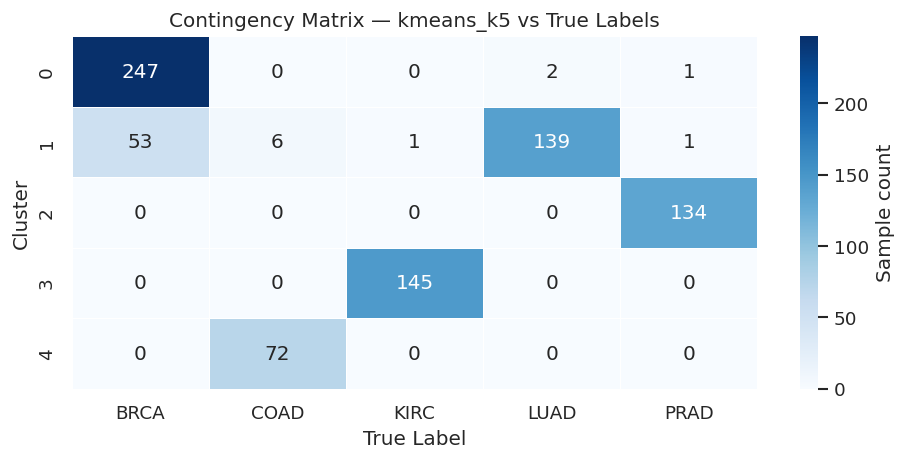

In [8]:
best_algo = pd.DataFrame(rows).sort_values("ARI", ascending=False).iloc[0]["Algorithm"]
print(f"Best algorithm by ARI: {best_algo}")

ct = pd.crosstab(
    assignments[best_algo].rename("Cluster"),
    true_labels.rename("True Label")
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", linewidths=0.4,
            cbar_kws={"label": "Sample count"}, ax=ax)
ax.set_title(f"Contingency Matrix — {best_algo} vs True Labels")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/best_contingency_matrix.png")
plt.show()

## 7. Save Embeddings & Metrics

In [9]:
# 2-D embeddings — used by Streamlit app
pd.DataFrame(X_tsne, columns=["x", "y"], index=assignments.index).to_csv(
    f"{DATA_DIR}/X_tsne.csv")
pd.DataFrame(X_umap, columns=["x", "y"], index=assignments.index).to_csv(
    f"{DATA_DIR}/X_umap.csv")

# Evaluation metrics table
pd.DataFrame(rows).to_csv(f"{DATA_DIR}/eval_metrics.csv", index=False)

# Save fitted UMAP model for Streamlit (transform new samples)
joblib.dump(umap_model, f"{MODELS_DIR}/umap.joblib")

print("Saved: data/X_tsne.csv")
print("Saved: data/X_umap.csv")
print("Saved: data/eval_metrics.csv")
print("Saved: models/umap.joblib")

Saved: data/X_tsne.csv
Saved: data/X_umap.csv
Saved: data/eval_metrics.csv
Saved: models/umap.joblib


## Evaluation Summary

**Metrics interpretation guide**

| Metric | Interpretation |
|---|---|
| **Silhouette** | Measures cluster compactness and separation without needing ground truth. A score above 0.5 indicates well-defined clusters; above 0.7 is considered strong. |
| **ARI** | Measures agreement with the true cancer subtype labels, adjusted for chance. A score near 1.0 means the clusters map almost perfectly onto subtypes; near 0 means no better than random. |
| **NMI** | Measures how much knowing the cluster assignment reduces uncertainty about the true label. Like ARI, 1.0 is perfect and 0 is no shared information. |

**Persisted artefacts**

| File | Contents | Used by |
|---|---|---|
| `data/X_tsne.csv` | 2D t-SNE coordinates | Streamlit app |
| `data/X_umap.csv` | 2D UMAP coordinates | Streamlit app |
| `data/eval_metrics.csv` | Silhouette / ARI / NMI per algorithm | Streamlit app |
| `models/umap.joblib` | Fitted UMAP model | Streamlit app (project uploaded samples) |

**Next step** — launch the interactive dashboard with:
```bash
streamlit run app/streamlit_app.py
```